# XGBoost Regression with a `log1p` Target

The model is trained on `np.log1p(charges)`. Predictions are converted back to the original scale with `np.expm1`, and all main metrics (RMSE, MAE, R2) are reported on that original `charges` scale.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1337 rows, 5 columns
Columns: ['age', 'bmi', 'children', 'charges', 'smoker_encoded']


,age,bmi,children,charges,smoker_encoded
0,19,27.900,0,16884.92400,1
1,18,33.770,1,1725.55230,0
2,28,33.000,3,4449.46200,0
3,33,22.705,0,21984.47061,0
4,32,28.880,0,3866.85520,0


## 1. Train/Test Split and Target Transform

After splitting the data, we transform the training target using `np.log1p` for XGBoost training (`y_train_log`).

In [4]:
from sklearn.model_selection import train_test_split

raw_feature_cols = [
    'age', 'bmi', 'children', 'smoker_encoded',
    # 'region_northwest', 'region_southeast', 'region_southwest', 'gender_encoded',
]

# Split first, then engineer features separately to keep evaluation setup clean.
X_raw = data_df[raw_feature_cols]
y = data_df['charges']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

def add_features(df):
    out = df.copy()
    out['age_squared'] = out['age'] ** 2
    out['smoker_bmi'] = out['smoker_encoded'] * out['bmi']
    return out

X_train = add_features(X_train_raw)
X_test = add_features(X_test_raw)

feature_cols = [
    'age', 'age_squared', 'bmi', 'children', 'smoker_encoded', 'smoker_bmi'
    # 'region_northwest', 'region_southeast', 'region_southwest', 'gender_encoded', 
]

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]
y_train_log = np.log1p(y_train)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1")

Training set: 1069 samples
Test set:     268 samples
Target for fitting: y_train_log = np.log1p(y_train); inverse at predict: np.expm1


## 2. Model Training (Tuned, Log-Target)

`RandomizedSearchCV` and early stopping use RMSE on **`log1p(charges)`**. Final predictions are then converted with `expm1` so evaluation is easy to interpret in the original dollar scale.

In [5]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Hold-out validation for early stopping is created from training data only.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_log, test_size=0.2, random_state=42
)

# Baseline uses the same early-stopping protocol as tuned model for fair comparison.
baseline_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=50,
)
baseline_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
baseline_best_rounds = int(baseline_model.best_iteration + 1)
y_pred_train_baseline = np.expm1(baseline_model.predict(X_train))
y_pred_test_baseline = np.expm1(baseline_model.predict(X_test))

base_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
)

param_dist = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0, 10.0],
    'n_estimators': [300, 500, 800],
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=80,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
search.fit(X_tr, y_tr)

tuned_params = search.best_params_.copy()

monitoring_model = XGBRegressor(
    **tuned_params,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    early_stopping_rounds=50,
)
monitoring_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

evals_result = monitoring_model.evals_result()
tuned_n_estimators = int(monitoring_model.best_iteration + 1)

# Refit uses early stopping again (no heuristic multiplier).
X_full_tr, X_full_val, y_full_tr, y_full_val = train_test_split(
    X_train, y_train_log, test_size=0.1, random_state=123
)
model = XGBRegressor(
    **{k: v for k, v in tuned_params.items() if k != 'n_estimators'},
    n_estimators=2000,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    early_stopping_rounds=50,
)
model.fit(
    X_full_tr,
    y_full_tr,
    eval_set=[(X_full_val, y_full_val)],
    verbose=False,
)
final_best_rounds = int(model.best_iteration + 1)

y_pred_train = np.expm1(model.predict(X_train))
y_pred_test = np.expm1(model.predict(X_test))

print('XGBoost tuning completed (target: log1p(charges)).')
print('Metrics in the next section use original scale (expm1).')
print('Best params:', tuned_params)
print(f'Baseline best boosting rounds: {baseline_best_rounds}')
print(f'Tuned best boosting rounds (monitoring): {tuned_n_estimators}')
print(f'Final refit best boosting rounds: {final_best_rounds}')

XGBoost tuning completed (target: log1p(charges)).
Metrics in the next section use original scale (expm1).
Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Baseline best boosting rounds: 64
Tuned best boosting rounds (monitoring): 409
Final refit best boosting rounds: 526


## 3. Model Evaluation (R2, RMSE, MAE on Original `charges`)

Here, original `y_train` and `y_test` are compared against predictions after applying `expm1`.

In [6]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return np.mean(2.0 * np.abs(y_true - y_pred) / denom) * 100


# Tuned model metrics (original dollar scale)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_train = mape(y_train, y_pred_train)
mape_test = mape(y_test, y_pred_test)
smape_train = smape(y_train, y_pred_train)
smape_test = smape(y_test, y_pred_test)

# Baseline metrics (before tuning)
r2_train_base = r2_score(y_train, y_pred_train_baseline)
r2_test_base = r2_score(y_test, y_pred_test_baseline)
rmse_train_base = np.sqrt(mean_squared_error(y_train, y_pred_train_baseline))
rmse_test_base = np.sqrt(mean_squared_error(y_test, y_pred_test_baseline))
mae_train_base = mean_absolute_error(y_train, y_pred_train_baseline)
mae_test_base = mean_absolute_error(y_test, y_pred_test_baseline)
mape_train_base = mape(y_train, y_pred_train_baseline)
mape_test_base = mape(y_test, y_pred_test_baseline)
smape_train_base = smape(y_train, y_pred_train_baseline)
smape_test_base = smape(y_test, y_pred_test_baseline)

metrics = pd.DataFrame({
    'Metric': ['R2', 'RMSE', 'MAE', 'MAPE (%)', 'sMAPE (%)'],
    'Train': [r2_train, rmse_train, mae_train, mape_train, smape_train],
    'Test': [r2_test, rmse_test, mae_test, mape_test, smape_test]
})

comparison_before_after = pd.DataFrame([
    {
        'Model': 'Baseline',
        'R2_train': r2_train_base,
        'R2_test': r2_test_base,
        'RMSE_train': rmse_train_base,
        'RMSE_test': rmse_test_base,
        'MAE_train': mae_train_base,
        'MAE_test': mae_test_base,
        'MAPE_train': mape_train_base,
        'MAPE_test': mape_test_base,
        'sMAPE_train': smape_train_base,
        'sMAPE_test': smape_test_base,
    },
    {
        'Model': 'Tuned',
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAE_train': mae_train,
        'MAE_test': mae_test,
        'MAPE_train': mape_train,
        'MAPE_test': mape_test,
        'sMAPE_train': smape_train,
        'sMAPE_test': smape_test,
    }
])

print('Model performance (original charges; y vs expm1 predictions):\n')
print(metrics.to_string(index=False, formatters={
    'Train': lambda x: f'{x:,.4f}' if x < 100 else f'{x:,.0f}',
    'Test': lambda x: f'{x:,.4f}' if x < 100 else f'{x:,.0f}',
}))

print('\nBefore vs After Tuning:\n')
display(comparison_before_after.style.format({
    'R2_train': '{:.4f}', 'R2_test': '{:.4f}',
    'RMSE_train': '{:,.0f}', 'RMSE_test': '{:,.0f}',
    'MAE_train': '{:,.0f}', 'MAE_test': '{:,.0f}',
    'MAPE_train': '{:.2f}%', 'MAPE_test': '{:.2f}%',
    'sMAPE_train': '{:.2f}%', 'sMAPE_test': '{:.2f}%'
}))

Model performance (original charges; y vs expm1 predictions):

   Metric   Train    Test
       R2  0.8605  0.8963
     RMSE   4,371   4,364
      MAE   1,942   1,998
 MAPE (%) 16.8867 17.6937
sMAPE (%) 17.9408 18.1725

Before vs After Tuning:



,Model,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test,MAPE_train,MAPE_test,sMAPE_train,sMAPE_test
0,Baseline,0.8514,0.8837,"4,511","4,623","2,095","2,222",17.85%,18.78%,18.71%,19.02%
1,Tuned,0.8605,0.8963,"4,371","4,364","1,942","1,998",16.89%,17.69%,17.94%,18.17%


## 3b. Nested Cross-Validation (Outer 5-Fold, Inner Tuning)

To estimate full pipeline generalization (including hyperparameter selection), we use nested CV: an inner `RandomizedSearchCV` chooses hyperparameters on each outer-training split, and evaluation is reported on each outer-validation split in the original `charges` scale.

In [7]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=123)

nested_results = []

for fold_idx, (train_idx, valid_idx) in enumerate(outer_cv.split(X_train), start=1):
    X_outer_train = X_train.iloc[train_idx]
    y_outer_train = y_train.iloc[train_idx]
    X_outer_valid = X_train.iloc[valid_idx]
    y_outer_valid = y_train.iloc[valid_idx]

    y_outer_train_log = np.log1p(y_outer_train)

    inner_search = RandomizedSearchCV(
        estimator=XGBRegressor(
            objective='reg:squarederror',
            eval_metric='rmse',
            random_state=42,
        ),
        param_distributions=param_dist,
        n_iter=40,
        scoring='neg_root_mean_squared_error',
        cv=inner_cv,
        random_state=42 + fold_idx,
        n_jobs=-1,
        verbose=0,
    )
    inner_search.fit(X_outer_train, y_outer_train_log)

    best_params_outer = inner_search.best_params_.copy()
    outer_model = XGBRegressor(
        **best_params_outer,
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=42,
    )
    outer_model.fit(X_outer_train, y_outer_train_log)

    y_outer_pred = np.expm1(outer_model.predict(X_outer_valid))

    nested_results.append({
        'Fold': f'Fold {fold_idx}',
        'Best RMSE (inner, log-scale)': -inner_search.best_score_,
        'RMSE (outer)': np.sqrt(mean_squared_error(y_outer_valid, y_outer_pred)),
        'MAE (outer)': mean_absolute_error(y_outer_valid, y_outer_pred),
        'R2 (outer)': r2_score(y_outer_valid, y_outer_pred),
    })

nested_cv_result = pd.DataFrame(nested_results)
nested_cv_summary = pd.DataFrame({
    'Metric': ['RMSE (outer)', 'MAE (outer)', 'R2 (outer)'],
    'Mean (Outer 5-Fold)': [
        nested_cv_result['RMSE (outer)'].mean(),
        nested_cv_result['MAE (outer)'].mean(),
        nested_cv_result['R2 (outer)'].mean(),
    ],
    'Std Dev': [
        nested_cv_result['RMSE (outer)'].std(ddof=1),
        nested_cv_result['MAE (outer)'].std(ddof=1),
        nested_cv_result['R2 (outer)'].std(ddof=1),
    ]
})

print('Per-fold nested CV scores:')
display(nested_cv_result.style.format({
    'Best RMSE (inner, log-scale)': '{:,.4f}',
    'RMSE (outer)': '{:,.2f}',
    'MAE (outer)': '{:,.2f}',
    'R2 (outer)': '{:.4f}',
}))

print('\nNested CV summary (outer mean ± std):')
display(nested_cv_summary.style.format({'Mean (Outer 5-Fold)': '{:,.4f}', 'Std Dev': '{:,.4f}'}))

Per-fold nested CV scores:


,Fold,"Best RMSE (inner, log-scale)",RMSE (outer),MAE (outer),R2 (outer)
0,Fold 1,0.3917,"4,696.36","2,218.78",0.8252
1,Fold 2,0.3889,"4,535.78","2,091.90",0.8374
2,Fold 3,0.4038,"4,284.00","2,063.66",0.8891
3,Fold 4,0.3739,"5,043.78","2,418.37",0.7964
4,Fold 5,0.3934,"4,907.87","2,216.05",0.8284



Nested CV summary (outer mean ± std):


,Metric,Mean (Outer 5-Fold),Std Dev
0,RMSE (outer),"4,693.5582",300.5086
1,MAE (outer),"2,201.7538",140.1383
2,R2 (outer),0.8353,0.0338


## 4. Feature Importance (XGBoost)

Feature Importance (XGBoost):

  smoker_encoded            :       0.4860
  smoker_bmi                :       0.2255
  age_squared               :       0.1155
  age                       :       0.1137
  children                  :       0.0423
  bmi                       :       0.0170


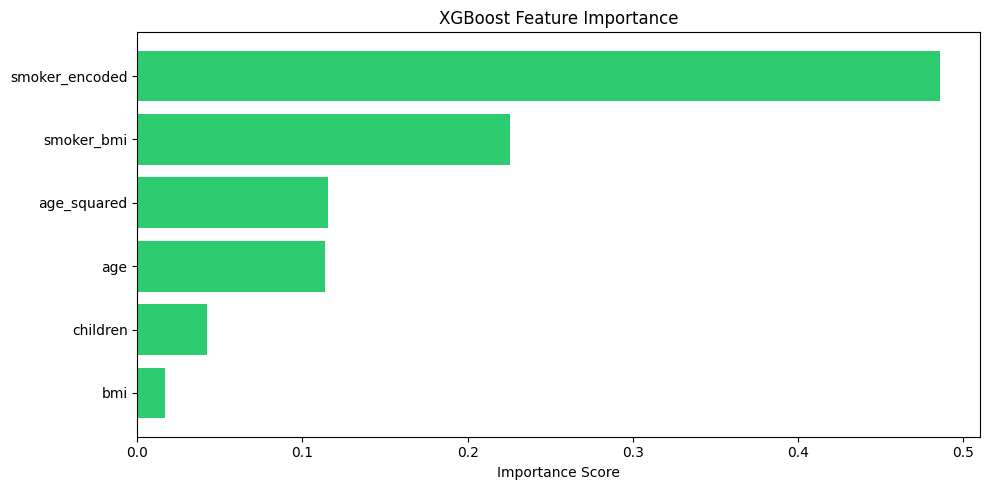

In [8]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (XGBoost):\n")
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Importance']:>12.4f}")

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2ecc71')
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Residual analysis (original `charges`)

Residual normality (Shapiro): W=0.5215, p=0.0000
Heteroskedasticity (Spearman |resid| vs pred): rho=0.190, p=0.0018


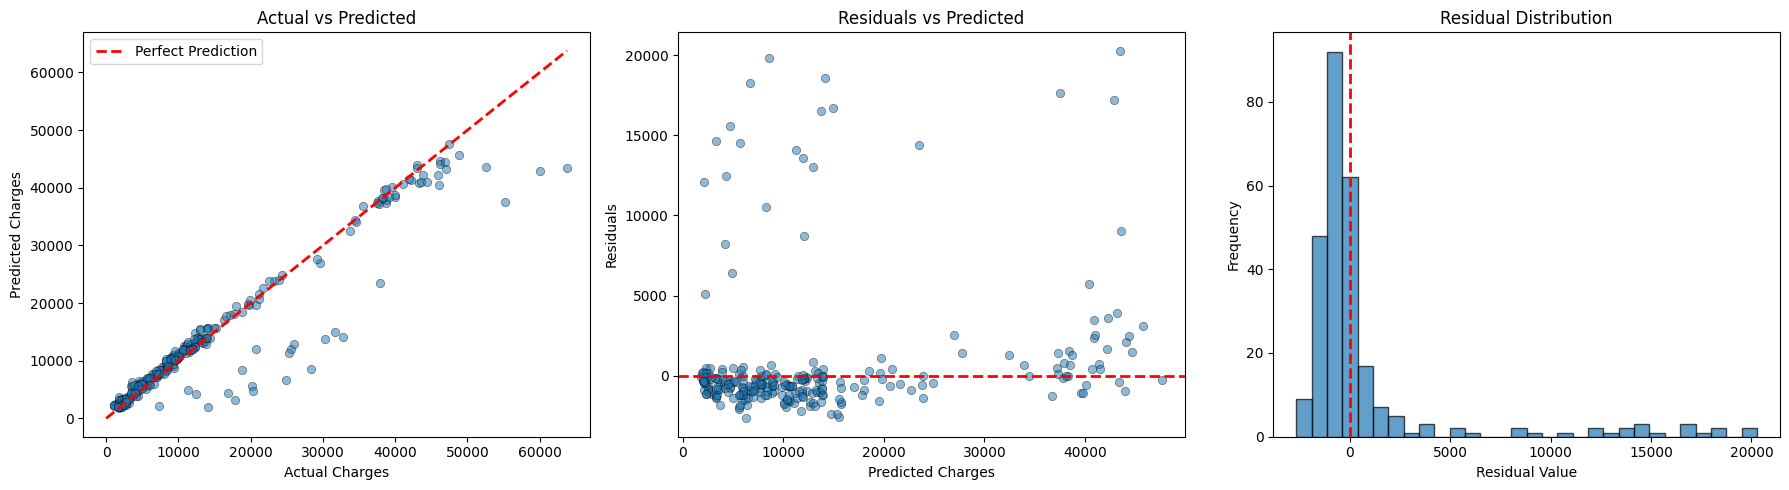

In [9]:
from scipy import stats

residuals = y_test - y_pred_test

# Shapiro is reliable for smaller samples; cap to 500 for stability and speed.
shapiro_sample = residuals.iloc[: min(500, len(residuals))]
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)
print(f"Residual normality (Shapiro): W={shapiro_stat:.4f}, p={shapiro_p:.4f}")

# Spearman(|residual|, prediction) as a practical heteroskedasticity signal.
spearman_rho, spearman_p = stats.spearmanr(y_pred_test, np.abs(residuals))
print(f"Heteroskedasticity (Spearman |resid| vs pred): rho={spearman_rho:.3f}, p={spearman_p:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 5b. Inspect Rows with the Largest Residuals and Export to CSV

The table below sorts the **test set** by `|y_actual - y_pred|` (original scale). The `residual_log` column compares the log-space target (`log1p`) against the model's raw output. The CSV file stores the **top N** rows for spreadsheet review.

In [10]:
TOP_N = 25
OUT_CSV = "xgboost_log_reg_top_residuals_test.csv"

inspect_df = X_test.copy()
inspect_df.insert(0, "original_row_index", X_test.index.to_numpy())
inspect_df["y_actual"] = np.asarray(y_test)
inspect_df["y_pred"] = np.asarray(y_pred_test)
inspect_df["residual"] = inspect_df["y_actual"] - inspect_df["y_pred"]
inspect_df["abs_error"] = inspect_df["residual"].abs()
inspect_df["pct_abs_error"] = (
    inspect_df["abs_error"] / inspect_df["y_actual"].replace(0, np.nan) * 100
)

y_log_actual = np.log1p(inspect_df["y_actual"].to_numpy(dtype=float))
y_log_pred = model.predict(X_test)
inspect_df["residual_log"] = y_log_actual - y_log_pred
inspect_df["abs_error_log"] = np.abs(inspect_df["residual_log"])

inspect_sorted = inspect_df.sort_values("abs_error", ascending=False)
display(
    inspect_sorted.head(TOP_N).style.format(
        {
            "y_actual": "{:,.2f}",
            "y_pred": "{:,.2f}",
            "residual": "{:,.2f}",
            "abs_error": "{:,.2f}",
            "pct_abs_error": "{:.2f}",
            "residual_log": "{:.4f}",
            "abs_error_log": "{:.4f}",
        },
        na_rep="—",
    )
)

inspect_sorted.head(TOP_N).to_csv(OUT_CSV, index=False)
print(f"Exported top {TOP_N} rows by |residual| (original scale) to: {OUT_CSV}")

,original_row_index,age,age_squared,bmi,children,smoker_encoded,smoker_bmi,y_actual,y_pred,residual,abs_error,pct_abs_error,residual_log,abs_error_log
543,543,54,2916,47.410000,0,1,47.410000,"63,770.43","43,495.52","20,274.91","20,274.91",31.79,0.3826,0.3826
986,986,45,2025,27.645000,1,0,0.000000,"28,340.19","8,518.92","19,821.27","19,821.27",69.94,1.2019,1.2019
128,128,32,1024,17.765000,2,1,17.765000,"32,734.19","14,151.25","18,582.94","18,582.94",56.77,0.8386,0.8386
636,636,35,1225,38.095000,2,0,0.000000,"24,915.05","6,634.25","18,280.79","18,280.79",73.37,1.3231,1.3231
818,818,33,1089,35.530000,0,1,35.530000,"55,135.40","37,510.29","17,625.11","17,625.11",31.97,0.3852,0.3852
1229,1229,52,2704,34.485000,3,1,34.485000,"60,021.40","42,844.45","17,176.95","17,176.95",28.62,0.3371,0.3371
573,573,62,3844,36.860000,1,0,0.000000,"31,620.00","14,937.36","16,682.64","16,682.64",52.76,0.7499,0.7499
115,115,60,3600,28.595000,0,0,0.000000,"30,260.00","13,762.70","16,497.30","16,497.30",54.52,0.7878,0.7878
291,291,29,841,29.640000,1,0,0.000000,"20,277.81","4,711.64","15,566.17","15,566.17",76.76,1.4593,1.4593
554,554,25,625,41.325000,0,0,0.000000,"17,878.90","3,242.96","14,635.94","14,635.94",81.86,1.7069,1.7069


Exported top 25 rows by |residual| (original scale) to: xgboost_log_reg_top_residuals_test.csv


This large residual is not a bug in the code and does not need to be removed from the data. It is the ceiling of the model's performance with currently available features. To significantly reduce this error, a richer feature domain is needed.

## 6. Training Monitoring (Learning Curve, RMSE in **log1p** Space)

This curve uses the same scale as early stopping. For business-facing interpretation, compare it with Section 3 metrics on the original scale.

Note: only one eval set found (`validation_0`), so train-vs-val gap is unavailable.


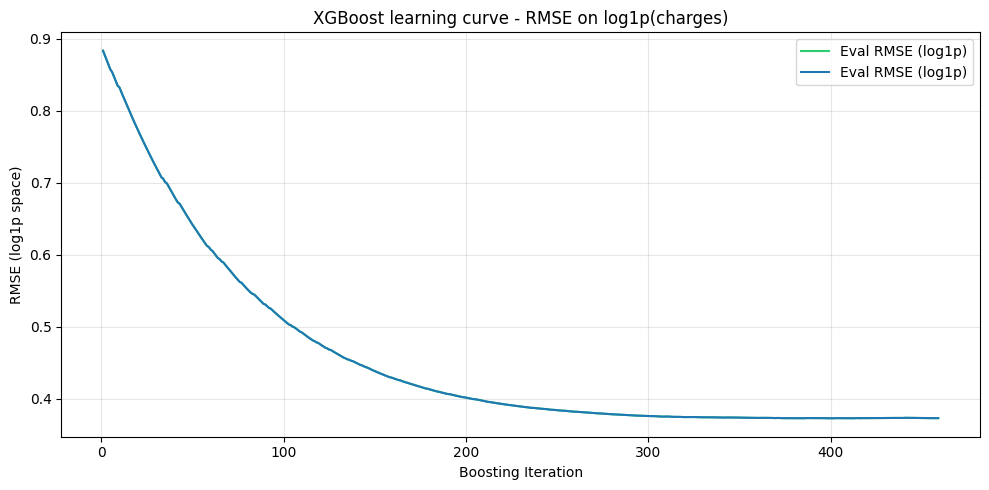

Best eval RMSE (log1p): 0.3731 at round 409


In [11]:
if 'evals_result' not in globals():
    raise RuntimeError("`evals_result` is not found. Run the tuning/monitoring cell first.")

if 'validation_1' in evals_result:
    train_rmse_curve = evals_result['validation_0']['rmse']
    val_rmse_curve = evals_result['validation_1']['rmse']
    train_label = 'Train RMSE (log1p)'
    val_label = 'Val RMSE (log1p)'
else:
    train_rmse_curve = evals_result['validation_0']['rmse']
    val_rmse_curve = evals_result['validation_0']['rmse']
    train_label = 'Eval RMSE (log1p)'
    val_label = 'Eval RMSE (log1p)'
    print("Note: only one eval set found (`validation_0`), so train-vs-val gap is unavailable.")

rounds = range(1, len(val_rmse_curve) + 1)

plt.figure(figsize=(10, 5))
plt.plot(rounds, train_rmse_curve, label=train_label, color='#2ecc71')
plt.plot(rounds, val_rmse_curve, label=val_label, color='#1f77b4')
plt.xlabel('Boosting Iteration')
plt.ylabel('RMSE (log1p space)')
plt.title('XGBoost learning curve - RMSE on log1p(charges)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_round = int(np.argmin(val_rmse_curve)) + 1
best_val_rmse = float(np.min(val_rmse_curve))
print(f'Best eval RMSE (log1p): {best_val_rmse:.4f} at round {best_round}')

if 'validation_1' in evals_result:
    final_gap = float(val_rmse_curve[-1] - train_rmse_curve[-1])
    print(f'Train-val RMSE gap   : {final_gap:.4f}')
    if final_gap > 0.08:
        print('Overfitting signal: val RMSE is much higher than train RMSE.')
    else:
        print('There is no strong overfitting signal.')

## 7. Export Trained model to ML Model

In [12]:
import copy
import json
from pathlib import Path
import coremltools as ct

# --- direct convert XGBoost → Core ML / ml model ---
# deepcopy so that the original booster does not mutate
booster_export = copy.deepcopy(model.get_booster())

coreml_model = ct.converters.xgboost.convert(
    booster_export,
    feature_names=feature_cols,
    target='annual_premium_log',
    force_32bit_float=True,
    mode='regressor',
)

# --- Add metadata ---
coreml_model.short_description = (
    "Insurance annual premium predictor (XGBoost, log1p target). "
    "Apply expm1() to output to get actual premium value."
)

# --- Save .mlpackage ---
out_path = Path("model.mlmodel")
coreml_model.save(str(out_path))

# --- Save metadata feature ---
metadata_path = Path("model.features.json")
feature_metadata = {
    "training_feature_order": feature_cols,
    "target_space": "log1p(annual_premium)",
    "postprocess": "expm1",
}
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, indent=2)

# --- Sanity check: original booster is not mutated ---
assert model.get_booster().feature_names == feature_cols, \
    "PERINGATAN: booster asli ikut termutasi!"

print(f"Saved Core ML model   : {out_path.resolve()}")
print(f"Saved feature metadata: {metadata_path.resolve()}")
print()
print("Feature order:")
for i, col in enumerate(feature_cols):
    print(f"  [{i:02d}] {col}")
print("\nSanity check passed: original booster is not mutated.")

ModuleNotFoundError: No module named 'coremltools'